# Kapasite Kısıtlı Çok Kalemli Stok Optimizasyonu

Bu notebook, ilk notebook'taki (`stok_optimizasyonu.ipynb`) tek kalemli modelleri **depo kapasitesi kısıtı altında çok kalemli** probleme genişletir.

1. **Kısıtlı çok kalemli EOQ** – Lagrange çarpanı yöntemi
2. **Çok dönemli parti büyüklüğü (lot-sizing) problemi** – karma tamsayılı doğrusal programlama (MILP), PuLP ile
3. **Duyarlılık analizi:** depo kapasitesi maliyeti nasıl etkiler?

> Kütüphane kurulumu: `pip install pulp`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp
from math import sqrt

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.3})

## Problem verisi

Üç ürün, ortak bir depo. Her ürünün yıllık talebi $D_i$, sipariş maliyeti $S_i$, birim elde tutma maliyeti $H_i$
ve birim başına kapladığı hacim $w_i$ (m³) var. Depo hacmi $W$.

In [2]:
items = ["A", "B", "C"]
D = {"A": 12000, "B": 6000, "C": 3000}      # yıllık talep
S = {"A": 100,   "B": 150,  "C": 200}       # sipariş maliyeti
H = {"A": 2.5,   "B": 4.0,  "C": 6.0}       # birim elde tutma maliyeti (yıllık)
w = {"A": 0.02,  "B": 0.05, "C": 0.10}      # birim hacim (m3)

pd.DataFrame({"D (yıllık talep)": D, "S (sipariş maliyeti)": S, "H (elde tutma)": H, "w (m3/birim)": w})

,D (yıllık talep),S (sipariş maliyeti),H (elde tutma),w (m3/birim)
A,12000,100,2.5,0.02
B,6000,150,4.0,0.05
C,3000,200,6.0,0.10


## 1. Kısıtlı çok kalemli EOQ

Kısıtsız EOQ her ürünü ayrı ayrı optimize eder: $Q_i^* = \sqrt{2D_iS_i/H_i}$.
Ancak ürünlerin en yüksek stok seviyeleri aynı anda depoya sığmak zorundaysa

$$\sum_i w_i Q_i \le W$$

kısıtı devreye girer. Lagrange çarpanı $\lambda \ge 0$ ile çözüm:

$$Q_i(\lambda) = \sqrt{\frac{2 D_i S_i}{H_i + 2\lambda w_i}}$$

$\lambda$ değeri, kısıt sağlanana kadar ikili aramayla (bisection) bulunur.

In [3]:
def eoq_unconstrained(D, S, H):
    return {i: sqrt(2 * D[i] * S[i] / H[i]) for i in D}

def total_cost(Q, D, S, H):
    return sum(D[i] * S[i] / Q[i] + H[i] * Q[i] / 2 for i in Q)

def eoq_constrained(D, S, H, w, W, tol=1e-9):
    Q0 = eoq_unconstrained(D, S, H)
    if sum(w[i] * Q0[i] for i in Q0) <= W:
        return Q0, 0.0
    Q_of = lambda lam: {i: sqrt(2 * D[i] * S[i] / (H[i] + 2 * lam * w[i])) for i in D}
    lo, hi = 0.0, 1.0
    while sum(w[i] * Q_of(hi)[i] for i in D) > W:
        hi *= 2
    for _ in range(200):
        mid = (lo + hi) / 2
        if sum(w[i] * Q_of(mid)[i] for i in D) > W:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return Q_of(hi), hi

Q0 = eoq_unconstrained(D, S, H)
W_eoq = 60                                    # depo hacmi (m3)
Qc, lam = eoq_constrained(D, S, H, w, W_eoq)

print(f"Kısıtsız EOQ'nun gerektirdiği hacim : {sum(w[i]*Q0[i] for i in items):.1f} m3  (depo: {W_eoq} m3)")
print(f"Lagrange çarpanı λ                  : {lam:.3f}")
print(f"Kısıtlı çözümün kullandığı hacim    : {sum(w[i]*Qc[i] for i in items):.1f} m3")
print(f"Kısıtsız yıllık maliyet             : {total_cost(Q0, D, S, H):,.0f}")
print(f"Kısıtlı yıllık maliyet              : {total_cost(Qc, D, S, H):,.0f}")

pd.DataFrame({"Q* (kısıtsız)": Q0, "Q* (kısıtlı)": Qc}).round(1)

Kısıtsız EOQ'nun gerektirdiği hacim : 97.9 m3  (depo: 60 m3)
Lagrange çarpanı λ                  : 63.448
Kısıtlı çözümün kullandığı hacim    : 60.0 m3
Kısıtsız yıllık maliyet             : 7,816
Kısıtlı yıllık maliyet              : 8,721


,Q* (kısıtsız),Q* (kısıtlı)
A,979.8,690.2
B,670.8,417.1
C,447.2,253.4


Depo küçüldüğünde tüm ürünlerin sipariş miktarı **birlikte** azalır; birim hacmi büyük olan ürünler (burada C) oransal olarak daha çok küçülür.
$\lambda$, bir metreküp ek depo alanının yıllık maliyet tasarrufu (gölge fiyat) olarak yorumlanabilir.

## 2. Çok dönemli parti büyüklüğü problemi (MILP)

EOQ sabit ve sürekli talep varsayar. Gerçekte talep **dönemden döneme** değişir. Bu bölümde 12 aylık, talebi bilinen
ve deponun ortak kullanıldığı bir planlama yapıyoruz.

**Karar değişkenleri**
- $x_{it}$: $t$ döneminde ürün $i$ için verilen sipariş miktarı
- $y_{it} \in \{0,1\}$: o dönemde sipariş verilip verilmediği
- $I_{it}$: dönem sonu stok

**Model**

$$\min \sum_{i,t} \left( S_i\, y_{it} + h_i\, I_{it} \right)$$

$$I_{i,t-1} + x_{it} - d_{it} = I_{it} \qquad x_{it} \le M\, y_{it} \qquad \sum_i w_i \,(I_{i,t-1} + x_{it}) \le W$$

Son kısıt, siparişler geldiği anda depoda bulunan toplam hacmin $W$'yi aşamayacağını söyler.

In [4]:
T = 12
rng = np.random.default_rng(7)
mevsim = 1 + 0.25 * np.sin(2 * np.pi * (np.arange(T) - 2) / 12)     # mevsimsel dalgalanma

d = {i: np.round(D[i] / T * mevsim * rng.uniform(0.9, 1.1, T)).astype(int) for i in items}
h = {i: H[i] / 12 for i in items}                                    # aylık elde tutma maliyeti

talep = pd.DataFrame(d, index=[f"Ay {t+1}" for t in range(T)])
talep.T

,Ay 1,Ay 2,Ay 3,Ay 4,Ay 5,Ay 6,Ay 7,Ay 8,Ay 9,Ay 10,Ay 11,Ay 12
A,803,945,1055,1063,1168,1343,1096,1197,1059,869,753,717
B,373,433,500,569,669,662,623,618,472,408,401,341
C,178,219,248,305,312,313,304,267,226,205,203,176


In [5]:
def solve_lot_sizing(d, S, h, w, W, T, items):
    prob = pulp.LpProblem("cok_kalemli_lot_sizing", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("x", (items, range(T)), lowBound=0)
    I = pulp.LpVariable.dicts("I", (items, range(T)), lowBound=0)
    y = pulp.LpVariable.dicts("y", (items, range(T)), cat="Binary")

    prob += pulp.lpSum(S[i] * y[i][t] + h[i] * I[i][t] for i in items for t in range(T))

    for i in items:
        M = int(sum(d[i]))
        for t in range(T):
            onceki = I[i][t - 1] if t > 0 else 0
            prob += onceki + x[i][t] - int(d[i][t]) == I[i][t]
            prob += x[i][t] <= M * y[i][t]

    if W is not None:
        for t in range(T):
            prob += pulp.lpSum(w[i] * ((I[i][t - 1] if t > 0 else 0) + x[i][t]) for i in items) <= W

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    durum = pulp.LpStatus[prob.status]
    if durum != "Optimal":
        return {"durum": durum}

    siparis = pd.DataFrame({i: [x[i][t].value() for t in range(T)] for i in items})
    stok = pd.DataFrame({i: [I[i][t].value() for t in range(T)] for i in items})
    hacim = [sum(w[i] * ((stok[i][t - 1] if t > 0 else 0) + siparis[i][t]) for i in items) for t in range(T)]
    return {"durum": durum, "maliyet": pulp.value(prob.objective),
            "siparis": siparis, "stok": stok, "hacim": np.array(hacim)}

# Talebin tek başına gerektirdiği en düşük depo hacmi
W_min = max(sum(w[i] * d[i][t] for i in items) for t in range(T))
print(f"Uygulanabilir olması için en az gereken depo hacmi ≈ {W_min:.1f} m3")

Uygulanabilir olması için en az gereken depo hacmi ≈ 91.3 m3


In [6]:
W_plan = 110
sonuc = solve_lot_sizing(d, S, h, w, W_plan, T, items)
print("Durum:", sonuc["durum"], "| Toplam maliyet:", round(sonuc["maliyet"], 1))

sonuc_serbest = solve_lot_sizing(d, S, h, w, None, T, items)
lot_for_lot = sum(S[i] for i in items for t in range(T) if d[i][t] > 0)

print(f"Kapasitesiz (W sınırsız) optimum maliyet : {sonuc_serbest['maliyet']:.1f}")
print(f"Kapasiteli (W = {W_plan} m3) optimum     : {sonuc['maliyet']:.1f}")
print(f"Her ay sipariş ver (lot-for-lot) maliyeti: {lot_for_lot:.1f}")
print(f"Lot-for-lot'a göre tasarruf              : {1 - sonuc['maliyet'] / lot_for_lot:.1%}")

sonuc["siparis"].round(0).astype(int).T.rename(columns=lambda c: f"Ay {c+1}")

Durum: Optimal | Toplam maliyet: 4996.5
Kapasitesiz (W sınırsız) optimum maliyet : 4886.5
Kapasiteli (W = 110 m3) optimum     : 4996.5
Her ay sipariş ver (lot-for-lot) maliyeti: 5400.0
Lot-for-lot'a göre tasarruf              : 7.5%


,Ay 1,Ay 2,Ay 3,Ay 4,Ay 5,Ay 6,Ay 7,Ay 8,Ay 9,Ay 10,Ay 11,Ay 12
A,803,945,1055,1063,1168,1343,1096,1197,1059,869,753,717
B,806,0,500,569,669,662,623,618,880,0,742,0
C,397,0,553,0,312,313,304,267,431,0,379,0


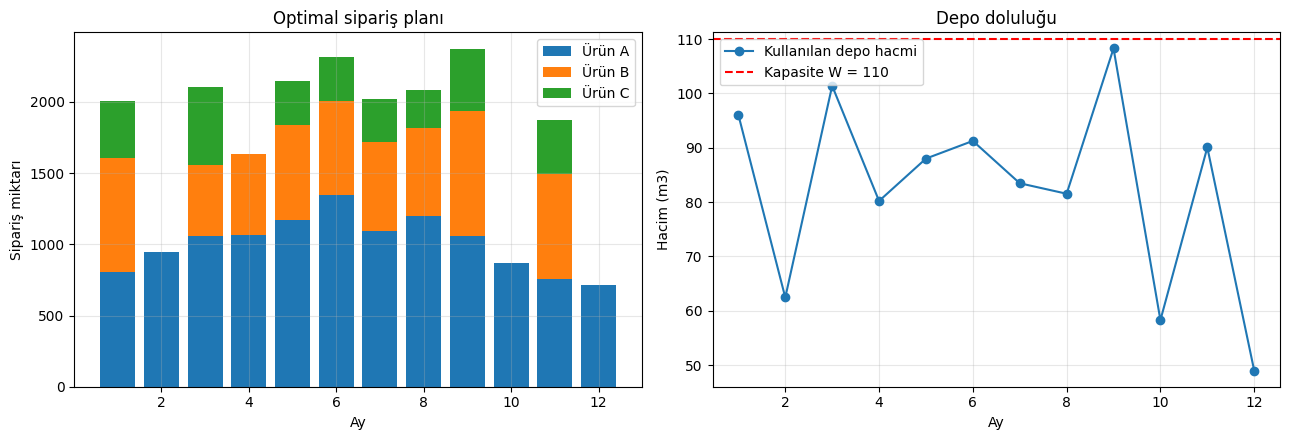

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

alt = np.zeros(T)
for i in items:
    ax[0].bar(range(1, T + 1), sonuc["siparis"][i], bottom=alt, label=f"Ürün {i}")
    alt += sonuc["siparis"][i].values
ax[0].set_xlabel("Ay"); ax[0].set_ylabel("Sipariş miktarı"); ax[0].set_title("Optimal sipariş planı")
ax[0].legend()

ax[1].plot(range(1, T + 1), sonuc["hacim"], "o-", label="Kullanılan depo hacmi")
ax[1].axhline(W_plan, color="red", ls="--", label=f"Kapasite W = {W_plan}")
ax[1].set_xlabel("Ay"); ax[1].set_ylabel("Hacim (m3)"); ax[1].set_title("Depo doluluğu")
ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Duyarlılık analizi: depo kapasitesi maliyeti nasıl etkiler?

Depo hacmi $W$'yi değiştirip aynı problemi çözüyoruz. Kapasite daraldıkça daha sık ve küçük siparişler gerekir,
dolayısıyla sipariş maliyeti artar.

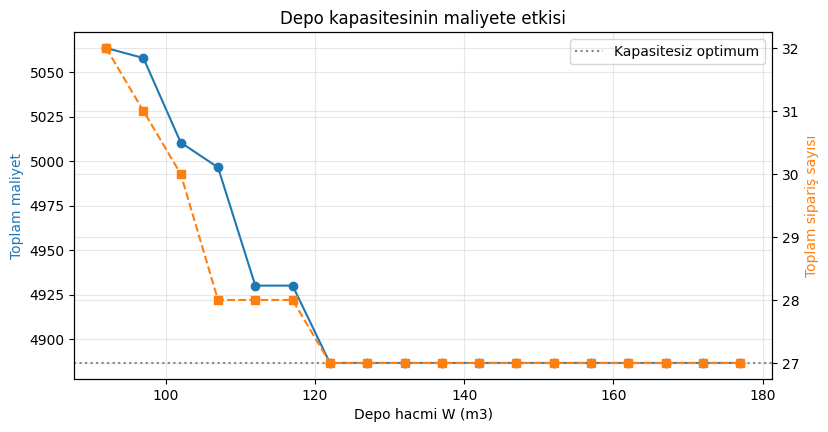

,W,maliyet,siparis_sayisi
0,92.0,5063.7,32
1,97.0,5058.0,31
2,102.0,5010.5,30
3,107.0,4996.5,28
4,112.0,4930.0,28
5,117.0,4930.0,28
6,122.0,4886.5,27
7,127.0,4886.5,27
8,132.0,4886.5,27
9,137.0,4886.5,27


In [8]:
kapasiteler = np.arange(np.ceil(W_min), 181, 5)
rows = []
for Wv in kapasiteler:
    r = solve_lot_sizing(d, S, h, w, float(Wv), T, items)
    if r["durum"] == "Optimal":
        rows.append({"W": Wv, "maliyet": r["maliyet"],
                     "siparis_sayisi": int((r["siparis"] > 0.5).sum().sum())})
duyarlilik = pd.DataFrame(rows)

fig, ax1 = plt.subplots()
ax1.plot(duyarlilik["W"], duyarlilik["maliyet"], "o-", color="tab:blue")
ax1.axhline(sonuc_serbest["maliyet"], color="gray", ls=":", label="Kapasitesiz optimum")
ax1.set_xlabel("Depo hacmi W (m3)"); ax1.set_ylabel("Toplam maliyet", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(duyarlilik["W"], duyarlilik["siparis_sayisi"], "s--", color="tab:orange")
ax2.set_ylabel("Toplam sipariş sayısı", color="tab:orange")
ax1.legend(loc="upper right")
plt.title("Depo kapasitesinin maliyete etkisi"); plt.show()

duyarlilik.round(1).head(12)

## Sonuç

- Depo kapasitesi kısıtı, kısıtsız EOQ çözümünü uygulanamaz kılar; Lagrange yöntemi tüm ürünlerin sipariş miktarını birlikte küçülterek en ucuz uygulanabilir çözümü verir.
- Talebi dönemden döneme değişen durumda MILP, hangi ayda hangi üründen ne kadar sipariş verileceğini **global optimum** olarak bulur ve düz "her ay sipariş ver" politikasına göre maliyeti düşürür.
- Kapasite arttıkça maliyet düşer ve bir noktadan sonra kısıt bağlayıcı olmaktan çıkar. Ek depo yatırımının değeri bu eğriden okunabilir.

**Sonraki adımlar**
- [ ] Bütçe (nakit) kısıtı eklemek
- [ ] Eksik stok / kayıp satış seçeneğini modele katmak
- [ ] Gerçek talep verisiyle çalıştırmak